# Experiment 1.1 compare with baseline methods

Random: AUC=0.3211, Low=0.2647, High=0.3775
Pre-Defined: AUC=0.4500, Low=0.3934, High=0.5065
25    0.683618
26    0.255345
27    0.315353
28    0.661721
29    0.599831
30    0.709501
31    0.644967
32    0.667547
33    0.690449
34    0.351408
35    0.686882
36    0.488203
37    0.650741
38    0.420043
39    0.680258
40    0.308426
41    0.644290
42    0.570202
43    0.538444
44    0.655951
45    0.349364
46    0.499632
47    0.560784
48    0.600031
49    0.317905
Name: auc, dtype: float64
SSL-NBV: AUC=0.5420, Low=0.4840, High=0.6000
Voxel-NBV: AUC=0.5750, Low=0.5166, High=0.6334
SSL-Semantic-NBV: AUC=0.5865, Low=0.5331, High=0.6399


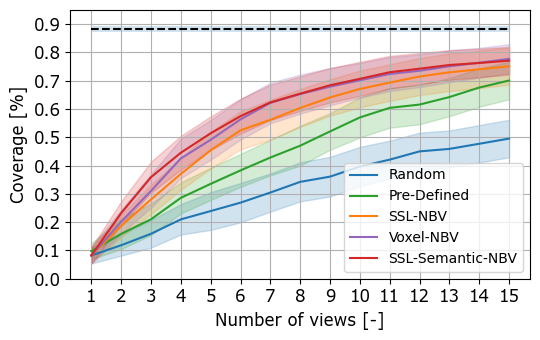

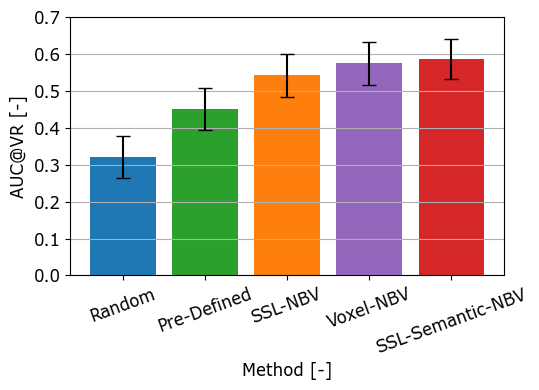

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

font_size = 12
verdana_path = '/home/jianchao/Downloads/Verdana.ttf'
verdana_font = fm.FontProperties(fname=verdana_path, size=font_size)
colors = ['#1F77B4', '#2CA02C', '#FF7F0E' , '#9467BD', '#D62728' ]

object_name = 'PLANT'
planner_name = ['random_global', 'predefined_global', 'ssl_nbv', 'voxel_global_nbv', 'ssl_semantic_nbv']
planner_plot_name = ['Random','Pre-Defined','SSL-NBV','Voxel-NBV','SSL-Semantic-NBV']

cov_index = ['cov_0','cov_1','cov_2', 'cov_3', 'cov_4', 'cov_5', 'cov_6', 'cov_7', 'cov_8', 'cov_9', 'cov_10', 'cov_11', 'cov_12', 'cov_13', 'cov_14']

plant_369_max_coverage_NODE = {
    'mean': 0.5996834709463044,
    'std': 0.054914641,
}
plant_369_max_coverage_FRUIT = {
    'mean': 0.507947028,
    'std': 0.045478395,
}
plant_369_max_coverage_PLANT = {
    'mean': 0.88271954,
    'std': 0.063818977,
}
number_runs_369 = 150

df = pd.read_csv('/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners/%s/results.csv' % object_name)

auc_list = []
auc_low_list = []
auc_high_list = []
plt.figure(figsize=(5.5, 3.5))
for idx, planner in enumerate(planner_name):
    df_planner = df[df['planner']==planner]
    coverage = df_planner[cov_index]
    plt.plot(coverage.mean(axis=0), label=planner_plot_name[idx], color=colors[idx])
    ci = 1.96 * (coverage.std(axis=0) / np.sqrt(len(coverage)))
    plt.fill_between(range(len(coverage.mean(axis=0))), 
                     coverage.mean(axis=0) - ci, 
                     coverage.mean(axis=0) + ci, 
                     alpha=0.2, color=colors[idx])
    
    AUC_average = df_planner['auc'].mean(axis=0)
    AUC_std = df_planner['auc'].std(axis=0)
    # Calculate 95% confidence interval instead of using std directly
    AUC_low = AUC_average - 1.96 * (AUC_std / np.sqrt(len(df_planner)))
    AUC_high = AUC_average + 1.96 * (AUC_std / np.sqrt(len(df_planner)))
    auc_list.append(AUC_average)
    auc_low_list.append(AUC_low)
    auc_high_list.append(AUC_high)
    if planner == 'ssl_nbv':
        print(df_planner['auc'])
        
    print(f"{planner_plot_name[idx]}: AUC={AUC_average:.4f}, Low={AUC_low:.4f}, High={AUC_high:.4f}")

#get object basd on the object_name
MAX_COVERAGE = eval('plant_369_max_coverage_%s' % object_name)
max_coverage_mean = MAX_COVERAGE['mean']
max_coverage_std = MAX_COVERAGE['std']

#copy the max_coverage_mean multiple times as the same length as the coverage
max_coverage_mean_list = [max_coverage_mean]*len(coverage.mean(axis=0))
max_coverage_low_list = [max_coverage_mean - (1.96 * max_coverage_std/np.sqrt(number_runs_369))]*len(coverage.mean(axis=0))
max_coverage_high_list = [max_coverage_mean + (1.96 * max_coverage_std/np.sqrt(number_runs_369))]*len(coverage.mean(axis=0))

x_ticks = [str(i+1) for i in range(len(coverage.mean(axis=0)))]

plt.plot(max_coverage_mean_list, color='black', linestyle='--')
plt.fill_between(range(len(max_coverage_mean_list)), 
                 max_coverage_low_list, 
                 max_coverage_high_list, 
                 alpha=0.2)

# fill an region as the 95% confidence interval
plt.xticks(range(len(coverage.mean(axis=0))), x_ticks, fontproperties=verdana_font)
plt.ylim(0, 0.95) # PLANT: 0.95, FRUIT: 0.6, NODE: 0.7
plt.yticks(np.arange(0, 0.96, 0.1), fontproperties=verdana_font)
plt.xlabel('Number of views [-]', fontproperties=verdana_font)
plt.ylabel('Coverage [%]', fontproperties=verdana_font)
plt.grid()
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners/coverage_{object_name}.png')
plt.show()

# plot the AUC for different planners using vertical bar plot
plt.figure(figsize=(5.5, 4))
#set colors align as the above plot

plt.bar(planner_plot_name, auc_list, color=colors, yerr=[np.array(auc_list) - np.array(auc_low_list), np.array(auc_high_list) - np.array(auc_list)], capsize=5)
plt.xlabel('Method [-]', fontproperties=verdana_font, fontweight='bold')
plt.ylabel('AUC@VR [-]', fontproperties=verdana_font, fontweight='bold')
plt.xticks(fontproperties=verdana_font, rotation=20)
plt.yticks(fontproperties=verdana_font)
plt.ylim(0, 0.7) # PLANT: 0.7, FRUIT: 0.5, NODE: 0.5
#grid only on the y axis
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners/AUC_{object_name}.png')
plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

font_size = 12
verdana_path = '/home/jianchao/Downloads/Verdana.ttf'
verdana_font = fm.FontProperties(fname=verdana_path, size=font_size)
colors = ['#1F77B4', '#2CA02C', '#FF7F0E' , '#9467BD', '#D62728' ]

object_name = ['PLANT', 'FRUIT', 'NODE']
planner_name = ['random_global', 'predefined_global', 'ssl_nbv', 'voxel_global_nbv', 'ssl_semantic_nbv']
planner_plot_name = ['Random','Pre-Defined','SSL-NBV','Voxel-NBV','SSL-Semantic-NBV']

cov_index = ['cov_0', 'cov_4', 'cov_9', 'cov_14']

plant_369_max_coverage_NODE = {
    'mean': 0.5996834709463044,
    'std': 0.054914641,
}
plant_369_max_coverage_FRUIT = {
    'mean': 0.507947028,
    'std': 0.045478395,
}
plant_369_max_coverage_PLANT = {
    'mean': 0.88271954,
    'std': 0.063818977,
}
number_runs_369 = 150

for object in object_name:
    df = pd.read_csv('/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners/%s/results.csv' % object)

    for idx, planner in enumerate(planner_name):
        df_planner = df[df['planner']==planner]
        coverage = df_planner[cov_index]    
        AUC_average = df_planner['auc'].mean(axis=0)

        #get object basd on the object_name
        MAX_COVERAGE = eval('plant_369_max_coverage_%s' % object)
        max_coverage_mean = MAX_COVERAGE['mean']

        print(f"{object}: {planner_plot_name[idx]}: Coverage={np.array(coverage.mean(axis=0))}, AUC={np.array(AUC_average):.4f}, Max Coverage={np.array(max_coverage_mean):.4f}")


PLANT: Random: Coverage=[0.08221864 0.23921844 0.39638367 0.49540612], AUC=0.3211, Max Coverage=0.8827
PLANT: Pre-Defined: Coverage=[0.09731875 0.33540035 0.57021402 0.70072888], AUC=0.4500, Max Coverage=0.8827
PLANT: SSL-NBV: Coverage=[0.08221864 0.45424468 0.67088902 0.75112807], AUC=0.5420, Max Coverage=0.8827
PLANT: Voxel-NBV: Coverage=[0.08221864 0.49121403 0.70150215 0.77742226], AUC=0.5750, Max Coverage=0.8827
PLANT: SSL-Semantic-NBV: Coverage=[0.08221864 0.51429935 0.70665414 0.77082404], AUC=0.5865, Max Coverage=0.8827
FRUIT: Random: Coverage=[0.04629622 0.11750085 0.17647558 0.23320656], AUC=0.1495, Max Coverage=0.5079
FRUIT: Pre-Defined: Coverage=[0.03157998 0.16046105 0.30592667 0.35658775], AUC=0.2339, Max Coverage=0.5079
FRUIT: SSL-NBV: Coverage=[0.04629622 0.24911477 0.33271703 0.35957073], AUC=0.2727, Max Coverage=0.5079
FRUIT: Voxel-NBV: Coverage=[0.04629622 0.2841904  0.38955496 0.39398602], AUC=0.3123, Max Coverage=0.5079
FRUIT: SSL-Semantic-NBV: Coverage=[0.04629622

# Experiment 1.2 Evaluate target-semantic mechanism

PLANT PLANT 0.5776895987186885
PLANT FRUIT 0.29357526326470057
PLANT NODE 0.35434492246914084
FRUIT PLANT 0.38706135459958074
FRUIT FRUIT 0.4142550923027002
FRUIT NODE 0.2899387556472617
NODE PLANT 0.5379016384162427
NODE FRUIT 0.33312057390133826
NODE NODE 0.4306488921746261


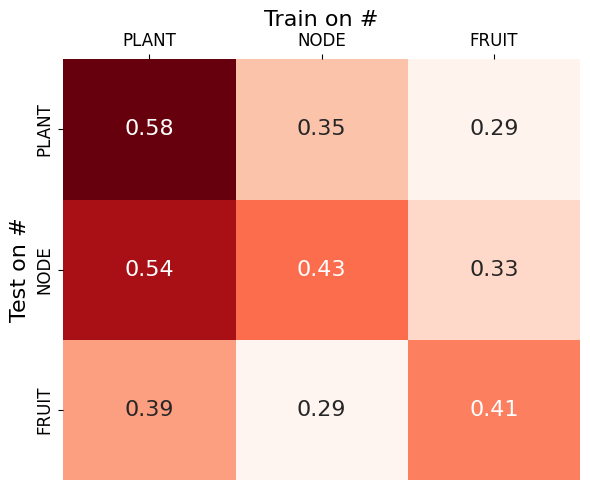

In [38]:
#draw me a confusion matrix using fake results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


train_targets = ['PLANT', 'FRUIT', 'NODE']
recon_targets = ['PLANT', 'FRUIT', 'NODE']

dir = '/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/test_semantic_aware'

results = dict()
for train_t in train_targets:
    for recon_t in recon_targets:
        csv_file = os.path.join(dir, f'train_{train_t}_recon_{recon_t}.csv')
        df = pd.read_csv(csv_file)
        df_auc = df['auc'].mean(axis=0)
        print(f'{train_t} {recon_t} {df_auc}')

        results[f'{train_t}_{recon_t}'] = df_auc

# Define class labels for semantic segmentation
class_labels = ['PLANT', 'NODE', 'FRUIT']

# Create a confusion matrix
results_re_ordered = np.zeros((len(class_labels), len(class_labels)))
for train_t in class_labels:
    for recon_t in class_labels:
        results_re_ordered[class_labels.index(train_t), class_labels.index(recon_t)] = results[f'{train_t}_{recon_t}']

plt.figure(figsize=(6, 5))
ax = sns.heatmap(results_re_ordered, annot=True, fmt='.2f', cmap='Reds', 
                 xticklabels=class_labels, yticklabels=class_labels, cbar=False,
                 annot_kws={'size': 16})

# Move x-axis labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Increase font size of tick labels
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.xlabel('Train on #', fontsize=16)
plt.ylabel('Test on #', fontsize=16)

plt.tight_layout()
plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/test_semantic_aware/confusion_matrix.png')
plt.show()

# Experiment 1.3 Abalation test

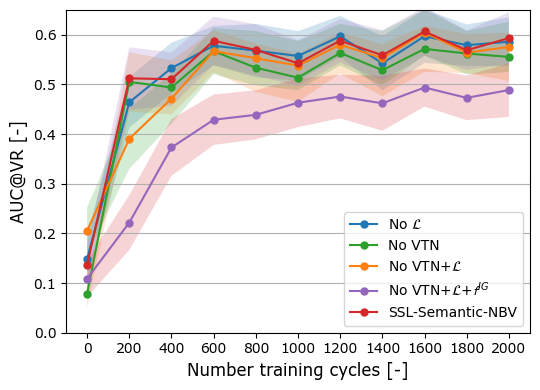

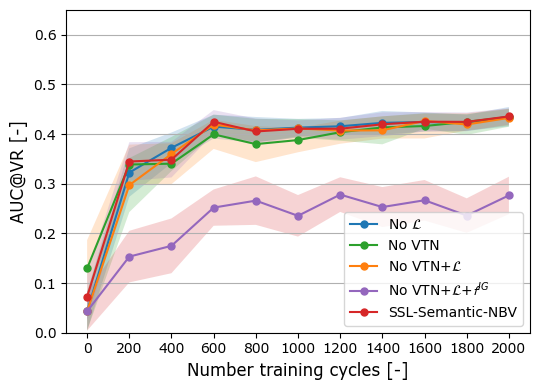

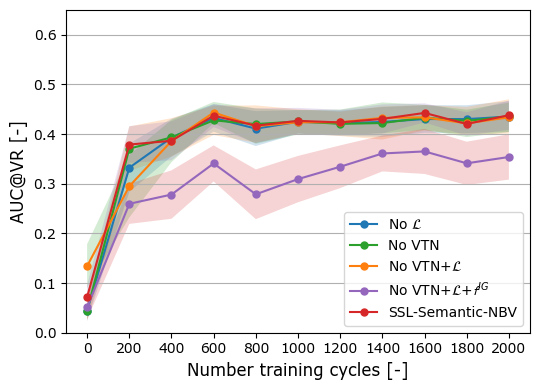

In [67]:
# draw the coverage of the proposed method and the baseline methods
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import matplotlib.font_manager as fm

font_size = 12
verdana_path = '/home/jianchao/Downloads/Verdana.ttf'
verdana_font = fm.FontProperties(fname=verdana_path, size=font_size)
colors = ['#1F77B4', '#2CA02C', '#FF7F0E' , '#9467BD', '#D62728']

results_dir = '/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/ablation_test'
targets = ['PLANT', 'FRUIT', 'NODE']

methods = ['ssl_semantic_nbv_NOLF', 'ssl_semantic_nbv_NOPE', 'ssl_semantic_nbv_NOPE_NOLF', 'ssl_semantic_nbv_NOPE_NOLF_NOIG', 'ssl_semantic_nbv']
plot_lables = ['No $\mathcal{L}$','No VTN','No VTN+$\mathcal{L}$','No VTN+$\mathcal{L}$+$\mathcal{f}^{IG}$',   'SSL-Semantic-NBV']

# methods = ['ssl_semantic_nbv_NOLF', 'ssl_semantic_nbv_NOPE_NOLF', 'ssl_semantic_nbv_NOPE_NOLF_NOIG', 'ssl_semantic_nbv']
# plot_lables = ['No $\mathcal{L}$','No VTN+$\mathcal{L}$','No VTN+$\mathcal{L}$+$\mathcal{f}^{IG}$',   'SSL-Semantic-NBV']

# methods = ['ssl_semantic_nbv_NOPE', 'ssl_semantic_nbv_NOPE_NOLF', 'ssl_semantic_nbv_NOPE_NOLF_NOIG', 'ssl_semantic_nbv']
# plot_lables = ['No VTN','No VTN+$\mathcal{L}$','No VTN+$\mathcal{L}$+$\mathcal{f}^{IG}$',   'SSL-Semantic-NBV']

# how to type script font L in python plot
# use font_manager to load the font

ckpts = np.arange(0, 2001, 200)

for target in targets:
    plt.figure(figsize=(5.5, 4))
    for method in methods:
        results_file = os.path.join(results_dir, f'{method}_{target}.csv')
        results = pd.read_csv(results_file)

        auc_mean_list = []
        auc_low_list = []
        auc_high_list = []
        for ckpt in ckpts:
            ckpt_table = results[results['ckpt'] == ckpt]
            auc_mean_list.append(ckpt_table['auc'].mean(axis=0))
            auc_low_list.append(ckpt_table['auc'].mean(axis=0) - 1.96 * (ckpt_table['auc'].std(axis=0) / np.sqrt(len(ckpt_table))))
            auc_high_list.append(ckpt_table['auc'].mean(axis=0) + 1.96 * (ckpt_table['auc'].std(axis=0) / np.sqrt(len(ckpt_table))))
            
        plt.plot(ckpts, auc_mean_list, marker='o', markersize=5, label=plot_lables[methods.index(method)], color=colors[methods.index(method)])
        # add 95% confidence interval
        plt.fill_between(ckpts, auc_low_list, auc_high_list, alpha=0.2)

    plt.xlabel('Number training cycles [-]', fontproperties=verdana_font)
    plt.xticks(ckpts, fontproperties=verdana_font, fontsize=10)
    plt.yticks(fontproperties=verdana_font, fontsize=10)
    plt.ylim(0, 0.65)
    plt.ylabel('AUC@VR [-]', fontproperties=verdana_font)
    #set x_ticks rotation to 20
    # plt.xticks(rotation=20)
    plt.grid(axis='y')
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/ablation_test/ablation_{target}.png')
    plt.show()


# Experiment 1.4 Evaluate occlusion handling

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import matplotlib.font_manager as fm

font_size = 12
verdana_path = '/home/jianchao/Downloads/Verdana.ttf'
verdana_font = fm.FontProperties(fname=verdana_path, size=font_size)
colors = ['#1F77B4', '#2CA02C', '#FF7F0E' , '#9467BD', '#D62728']

results_normal = '/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners'
results_occlusion = '/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/compare_diff_planners_heavy_occlusion'

targets = ['PLANT', 'FRUIT', 'NODE']
planner_name = ['random_global', 'predefined_global', 'ssl_nbv', 'voxel_global_nbv', 'ssl_semantic_nbv']
planner_plot_name = ['Random','Pre-Defined','SSL-NBV','Voxel-NBV','SSL-Semantic-NBV']

for target in targets:
    print('======================target: %s=========================' % target)
    for method in planner_name:
        normal_df = pd.read_csv(os.path.join(results_normal, target, 'results.csv'))
        occlusion_df = pd.read_csv(os.path.join(results_occlusion, target, 'results.csv'))
        normal_auc = normal_df[normal_df['planner']==method]['auc'].mean()
        occlusion_auc = occlusion_df[occlusion_df['planner']==method]['auc'].mean()
        print(f'{method} normal auc: {normal_auc}, occlusion auc: {occlusion_auc}, relative decrease: {100 * (normal_auc - occlusion_auc) / normal_auc}%')





======================target: PLANT=========================
random_global normal auc: 0.3211228251363625, occlusion auc: 0.23903073704005146, relative decrease: 25.564077564854262%
predefined_global normal auc: 0.4499540860853152, occlusion auc: 0.35879520759589345, relative decrease: 20.259595658419517%
ssl_nbv normal auc: 0.5420358485799046, occlusion auc: 0.45496400732112524, relative decrease: 16.063852877425248%
voxel_global_nbv normal auc: 0.5750088943935965, occlusion auc: 0.48350984017944576, relative decrease: 15.912632849035402%
ssl_semantic_nbv normal auc: 0.5865022162989273, occlusion auc: 0.49697492160987755, relative decrease: 15.264613193451197%
======================target: FRUIT=========================
random_global normal auc: 0.14948216308346454, occlusion auc: 0.14614555625543366, relative decrease: 2.232110346281158%
predefined_global normal auc: 0.23392119473627296, occlusion auc: 0.20266994958452167, relative decrease: 13.359732189716505%
ssl_nbv normal auc: 0.

# Experiment #4 Evaluate pre-training on synthetic plants

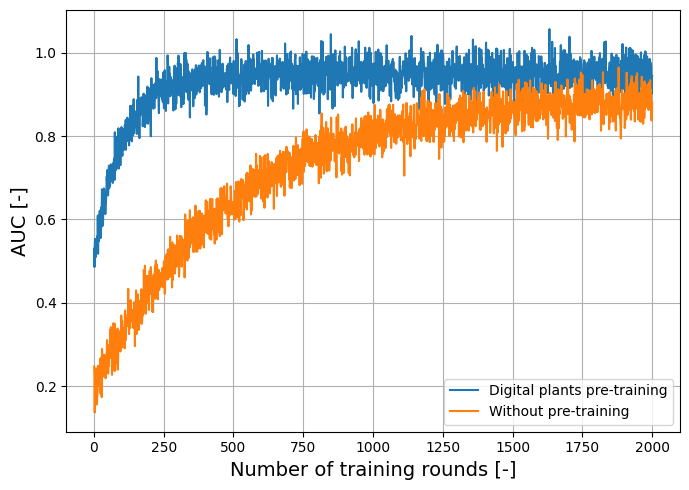

In [65]:
# draw the coverage of the proposed method and the baseline methods
import matplotlib.pyplot as plt
import numpy as np  
import os
import time

number_training = 2000
rounds =  np.arange(1, number_training+1)
methods = ['With digital plants pre-training', 'Without pre-training']

initial_auc_with_pre_training = 0.5
initial_auc_without_pre_training = 0.2

final_auc_with_pre_training = 0.95
final_auc_without_pre_training = 0.9

rate = 0.01

# Correct formula: initial + (final - initial) * (1 - exp(-rate * (x - 1)))
auc_with_pre_training = initial_auc_with_pre_training + (final_auc_with_pre_training - initial_auc_with_pre_training) * (1 - np.exp(-rate * (rounds - 1)))
auc_without_pre_training = initial_auc_without_pre_training + (final_auc_without_pre_training - initial_auc_without_pre_training) * (1 - np.exp(-rate/5 * (rounds - 1)))

# add noise to the auc_with_pre_training and auc_without_pre_training
auc_with_pre_training = auc_with_pre_training + np.random.normal(0, 0.03, size=len(rounds))
auc_without_pre_training = auc_without_pre_training + np.random.normal(0, 0.03, size=len(rounds))

plt.figure(figsize=(7, 5))
plt.plot(rounds, auc_with_pre_training, label='Digital plants pre-training')
plt.plot(rounds, auc_without_pre_training, label='Without pre-training')
plt.xlabel('Number of training rounds [-]', fontsize=14)
plt.ylabel('AUC [-]', fontsize=14)
plt.grid()
plt.legend()

# save the figure
plt.tight_layout()
plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/preliminary_results/auc.png')
plt.show()


In [ ]:
# train_plants = [11, 12, 14, 15, 17, 18, 20]  ##select the plants for training
# valid_plants = [13, 16, 19]  
# all_plants = train_plants + valid_plants

# nbv_data_path = '/home/jianchao/dataset/nbv_data/paper4/data_smaller_fov_distance'

# x_range = np.arange(-20, 20 + 1, 10)
# y_range = np.arange(-20, 20 + 1, 10)
# z_range = np.arange(0, 20 + 1, 20)
# rotation_range = np.arange(0, 360, 90)

# h_range = np.arange(0, 9, 1)
# w_range = np.arange(0, 9, 1)

# def get_pcd(plant, rotation, position: list, hw: list):
#     pcd_path = os.path.join(
#         nbv_data_path,
#         "plant%s" % str(plant),
#         "xyzr_%s_%s_%s_%s" % (str(position[0]), str(position[1]), str(position[2]), str(rotation)),
#         'pcd',
#         "pcd_%s_%s.npy" % (str(hw[0]), str(hw[1])),
#     )
#     pcd = np.load(pcd_path)
#     return pcd

# for plant in all_plants:    
#     for x in x_range:
#         for y in y_range:
#             for z in z_range:
#                 for rotation in rotation_range:
#                     for h in h_range:
#                         for w in w_range:
#                             print(plant, rotation, [x, y, z], [h, w])
#                             pcd = get_pcd(plant, rotation, [x, y, z], [h, w])
#                             print(pcd.shape)

(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 777, 6)
(1, 2100, 6)
(1, 2130, 6)
(1, 4275, 6)
(1, 2700, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 2885, 6)
(1, 7944, 6)
(1, 10102, 6)
(1, 12783, 6)
(1, 6205, 6)
(1, 2, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 746, 6)
(1, 5850, 6)
(1, 13176, 6)
(1, 13292, 6)
(1, 4231, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 257, 6)
(1, 7964, 6)
(1, 13402, 6)
(1, 10415, 6)
(1, 2561, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 187, 6)
(1, 6133, 6)
(1, 9297, 6)
(1, 7662, 6)
(1, 3651, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 29, 6)
(1, 3092, 6)
(1, 6924, 6)
(1, 3690, 6)
(1, 1570, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 776, 6)
(1, 4672, 6)
(1, 2954, 6)
(1, 265, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 878, 6)
(1, 923, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 1, 6)
(1, 325, 6)
(1, 3772, 6)
(1, 5120, 6)
(1, 6851, 6)
(1, 4

# Real world experiment compared different planners

NODE, Random: AUC=0.6401, Low=0.6187, High=0.6615
NODE, Pre-Defined: AUC=0.6754, Low=0.6538, High=0.6969
NODE, SSL-NBV: AUC=0.6538, Low=0.6356, High=0.6719
NODE, Voxel-NBV: AUC=0.6680, Low=0.6453, High=0.6906
NODE, SSL-Semantic-NBV: AUC=0.6572, Low=0.6356, High=0.6789


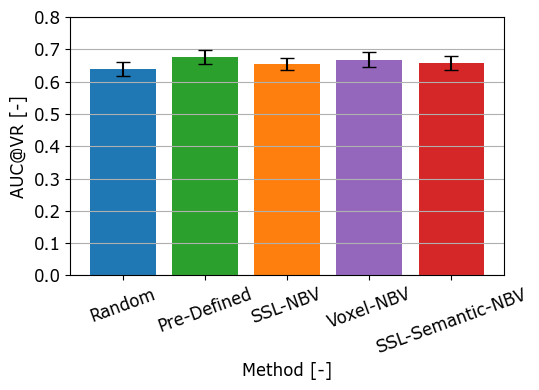

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

font_size = 12
verdana_path = '/home/jianchao/Downloads/Verdana.ttf'
verdana_font = fm.FontProperties(fname=verdana_path, size=font_size)
colors = ['#1F77B4', '#2CA02C', '#FF7F0E' , '#9467BD', '#D62728' ]

object_name = 'NODE'
planner_name = ['random_global', 'predefined_global', 'ssl_nbv', 'voxel_global_nbv', 'ssl_semantic_nbv']
planner_plot_name = ['Random','Pre-Defined','SSL-NBV','Voxel-NBV','SSL-Semantic-NBV']

cov_index = ['cov_0','cov_1','cov_2', 'cov_3', 'cov_4', 'cov_5', 'cov_6', 'cov_7', 'cov_8', 'cov_9', 'cov_10', 'cov_11', 'cov_12', 'cov_13', 'cov_14']

df = pd.read_csv('/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/real_world_experiments/%s/results.csv'%str(object_name))

auc_list = []
auc_low_list = []
auc_high_list = []
# plt.figure(figsize=(5.5, 3.5))
for idx, planner in enumerate(planner_name):
    df_planner = df[df['planner']==planner]
    coverage = df_planner[cov_index]
    
    AUC_average = df_planner['auc'].mean(axis=0)
    AUC_std = df_planner['auc'].std(axis=0)
    # Calculate 95% confidence interval instead of using std directly
    AUC_low = AUC_average - 1.96 * (AUC_std / np.sqrt(len(df_planner)))
    AUC_high = AUC_average + 1.96 * (AUC_std / np.sqrt(len(df_planner)))
    auc_list.append(AUC_average)
    auc_low_list.append(AUC_low)
    auc_high_list.append(AUC_high)
    
    print(f"{object_name}, {planner_plot_name[idx]}: AUC={AUC_average:.4f}, Low={AUC_low:.4f}, High={AUC_high:.4f}")

# plot the AUC for different planners using vertical bar plot
plt.figure(figsize=(5.5, 4))
plt.bar(planner_plot_name, auc_list, color=colors, yerr=[np.array(auc_list) - np.array(auc_low_list), np.array(auc_high_list) - np.array(auc_list)], capsize=5)
plt.xlabel('Method [-]', fontproperties=verdana_font, fontweight='bold')
plt.ylabel('AUC@VR [-]', fontproperties=verdana_font, fontweight='bold')
plt.xticks(fontproperties=verdana_font, rotation=20)
plt.yticks(fontproperties=verdana_font)
plt.ylim(0, 0.8) # PLANT: 0.7, FRUIT: 0.5, NODE: 0.5
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/drl_nbv_plan/materials/prilinary_test/real_world_experiments/REAL_AUC_{object_name}.png')
plt.show()